In [1]:
import numpy as np

import tensorflow as tf
import tensorflow.keras.layers as L
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn import model_selection

import matplotlib.pyplot as plt

2024-04-07 17:43:58.731245: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-07 17:43:58.731370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-07 17:43:58.863714: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.__version__

'2.15.0'

# Functions

## Plot Functions

In [3]:
def plot_results(y_predict, x, y):
    
    
    error = np.mean(np.square(y_predict-y)**2)
    random_slice = np.random.randint(0,y_predict.shape[0]+1)
    print(f'El error es {error}')

    fig, ax = plt.subplots(1, 2, figsize=(15,8))

    print(f'Las dimensiones del Y predict es {y_predict.shape}')
    print(f'Las dimensiones del Y normal es {y.shape}')

    im = ax[0].imshow(y_predict[random_slice,:,:])
    ax[0].set_title(f'Porosity Modeled. slice: {random_slice}')
    fig.colorbar(im, ax=ax[0], shrink=0.8)
    
    im2 = ax[1].imshow(y[random_slice,:,:])
    ax[1].set_title(f'Porosity Original. slice: {random_slice}')
    fig.colorbar(im2, ax=ax[1], shrink=0.8)
    fig.tight_layout()
    plt.show()

In [4]:
def plot_results_by_slices(y_predict, x, y, slice):

    
    error = np.mean(np.square(y_predict-y)**2)
    random_slice = np.random.randint(0,y_predict.shape[0]+1)
    print(f'El error es {error}')

    fig, ax = plt.subplots(1, 2, figsize=(15,8))

    print(f'Las dimensiones del Y predict es {y_predict.shape}')
    print(f'Las dimensiones del Y normal es {y.shape}')

    im = ax[0].imshow(y_predict[slice,:,:])
    ax[0].set_title(f'Porosity Modeled. slice: {slice}')
    fig.colorbar(im, ax=ax[0], shrink=0.8)
    
    im2 = ax[1].imshow(y[slice,:,:])
    ax[1].set_title(f'Porosity Original. slice: {slice}')
    fig.colorbar(im2, ax=ax[1], shrink=0.8)
    fig.tight_layout()
    
    fig.savefig(f'/kaggle/working/porosity_prediction_slice_{slice}.png')
    
    plt.show()

In [5]:
def visualizacion_entrenamiento(history, epocas):
    epochs = [i for i in range(epocas)]

    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']


    fig, ax = plt.subplots(1,2)
    #fig.set_size_inches(16,7)

    ax[0].plot(epochs, train_acc, 'go-', label='accuracy-train')
    ax[0].plot(epochs, val_acc, 'ro-', label='accuracy-val')
    ax[0].set_title('Accuracy train')
    ax[0].legend()
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')


    ax[1].plot(epochs, train_loss, 'go-', label='loss-train')
    ax[1].plot(epochs, val_loss, 'ro-', label='loss-val')
    ax[1].set_title('Loss train')
    ax[1].legend()
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    
    fig.savefig(f'/kaggle/working/training_history_for_{epocas}_epochs.png')
    
    plt.show()

## Load Data

In [6]:
def load_data():

    X_train = np.load('/kaggle/input/seismic-illinois-ccus-impedance-and-porosity/data_decatur/processed/train/impedance.npy')
    X_test = np.load('/kaggle/input/seismic-illinois-ccus-impedance-and-porosity/data_decatur/processed/test/impedance.npy')

    Y_train = np.load('/kaggle/input/seismic-illinois-ccus-impedance-and-porosity/data_decatur/processed/train/porosity.npy')
    Y_test = np.load('/kaggle/input/seismic-illinois-ccus-impedance-and-porosity/data_decatur/processed/test/porosity.npy')
    
    max_values_X = np.array([np.max(X_train), np.max(X_test)])
    min_values_X = np.array([np.min(X_train), np.min(X_test)])
    print(f'Los valores maximos de impedancia en test son: {max_values_X}')
    print(f'Los valores mínimos de impedancia en test son: {min_values_X}')

    max_X = np.max(max_values_X)
    min_X = np.min(min_values_X)
    print(f'Los valores maximos de impedancia en test son: {max_X}')
    print(f'Los valores mínimos de impedancia en test son: {min_X}')

    X_train = (X_train - min_X)/(max_X - min_X)
    X_test = (X_test - min_X)/(max_X - min_X)

    X_test,X_val,Y_test,Y_val = model_selection.train_test_split(X_test,Y_test, test_size=0.5, random_state=1,shuffle=False)
    
    number_train = np.random.randint(0,X_train.shape[0])

    number_test = np.random.randint(0,X_test.shape[0])

    fig, ax = plt.subplots(2,2)

    im = ax[0,0].imshow(X_train[number_train,:,:])
    ax[0,0].set_title('Impedance Train')
    fig.colorbar(im, ax=ax[0,0], shrink=0.8)

    im2 = ax[0,1].imshow(Y_train[number_train,:,:])
    ax[0,1].set_title('Porosity Train')
    fig.colorbar(im2, ax=ax[0,1], shrink=0.8)

    im3 = ax[1,0].imshow(X_test[number_test,:,:])
    ax[1,0].set_title('Impedance Test')
    fig.colorbar(im3, ax=ax[1,0], shrink=0.8)

    im4 = ax[1,1].imshow(Y_test[number_test,:,:])
    ax[1,1].set_title('Porosity Test')
    fig.colorbar(im4, ax=ax[1,1], shrink=0.8)

    plt.show()
    return X_train,Y_train,X_test,Y_test,X_val, Y_val


## Normalize Data

# Neural Network Architecture

## Building Blocks

In [7]:
def conv_block(x, num_filters):
    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    return x

In [8]:
def encoder_block(x, num_filters):
    x = conv_block(x, num_filters)
    p = L.MaxPool2D((2, 2))(x)
    return x, p

In [ ]:
def attention_gate(g, s, num_filters):
    Wg = L.Conv2D(num_filters, 1, padding="same")(g)
    Wg = L.BatchNormalization()(Wg)

    Ws = L.Conv2D(num_filters, 1, padding="same")(s)
    Ws = L.BatchNormalization()(Ws)

    out = L.Activation("relu")(Wg + Ws)
    out = L.Conv2D(num_filters, 1, padding="same")(out)
    out = L.Activation("sigmoid")(out)

    return out * s

In [ ]:
def decoder_block(x, s, num_filters):
    x = L.UpSampling2D(interpolation="bilinear")(x)
    s = attention_gate(x, s, num_filters)
    x = L.Concatenate()([x, s])
    x = conv_block(x, num_filters)
    return x

In [ ]:
def attention_unet(input_shape):
    """ Inputs """
    inputs = L.Input(input_shape)

    """ Encoder """
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)

    b1 = conv_block(p3, 512)

    """ Decoder """
    d1 = decoder_block(b1, s3, 256)
    d2 = decoder_block(d1, s2, 128)
    d3 = decoder_block(d2, s1, 64)

    """ Outputs """
    outputs = L.Conv2D(1, 1, padding="same", activation="sigmoid")(d3)

    """ Model """
    model = Model(inputs, outputs, name="Attention-UNET")
    return model

# Training

Los valores maximos de impedancia en test son: [72393.     70937.4375]
Los valores mínimos de impedancia en test son: [20215.82421875     0.        ]
Los valores maximos de impedancia en test son: 72393.0
Los valores mínimos de impedancia en test son: 0.0


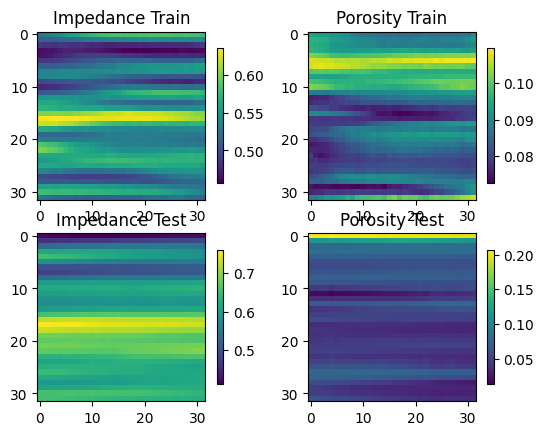

El shape del X_train es: (19641, 32, 32, 1)
El shape del X_val es: (2456, 32, 32, 1)
El shape del X_test es: (2455, 32, 32, 1)
El shape del Y_train es: (19641, 32, 32, 1)
El shape del Y_val es: (2456, 32, 32, 1)
El shape del Y_test es: (2455, 32, 32, 1)


In [9]:
X_train,Y_train,X_test,Y_test,X_val, Y_val = load_data()

X_train = tf.expand_dims(X_train, axis=-1)
X_val = tf.expand_dims(X_val, axis=-1)
X_test = tf.expand_dims(X_test, axis=-1)

Y_train = tf.expand_dims(Y_train, axis=-1)
Y_val = tf.expand_dims(Y_val, axis=-1)
Y_test = tf.expand_dims(Y_test, axis=-1)

print(f'El shape del X_train es: {X_train.shape}')
print(f'El shape del X_val es: {X_val.shape}')
print(f'El shape del X_test es: {X_test.shape}')
print(f'El shape del Y_train es: {Y_train.shape}')
print(f'El shape del Y_val es: {Y_val.shape}')
print(f'El shape del Y_test es: {Y_test.shape}')

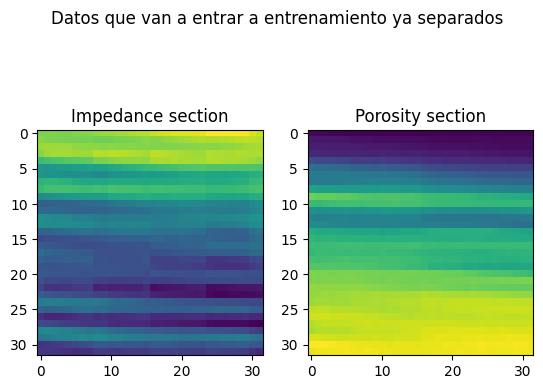

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 16, 16,    │      1,024 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 8, 8, 128) │    131,584 │ sequential[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 4, 4, 256) │    525,312 │ sequential_1[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 2, 2, 512) │  2,099,200 │ sequential_2[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 1, 1, 512) │  4,196,352 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 2, 2, 512) │  4,196,352 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_5[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 4, 4, 256) │  4,195,328 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4, 512) │          0 │ sequential_6[0][… │
│ (Concatenate)       │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 8, 8, 128) │  1,049,088 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 256) │          0 │ sequential_7[0][… │
│ (Concatenate)       │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 16, 16,    │    262,400 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 128)              │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 32, 32, 1) │      2,049 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,658,689 (63.55 MB)

 Trainable params: 16,653,953 (63.53 MB)

 Non-trainable params: 4,736 (18.50 KB)

None


In [10]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(X_train[1,:,:])
ax[0].set_title('Impedance section')
ax[1].imshow(Y_train[1,:,:])
ax[1].set_title('Porosity section')
fig.suptitle('Datos que van a entrar a entrenamiento ya separados')
plt.show()

train_images_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(Y_train)
test_images_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(Y_test)
validation_images_dataset = tf.data.Dataset.from_tensor_slices(X_val)
validation_labels_dataset = tf.data.Dataset.from_tensor_slices(Y_val)

train_dataset = tf.data.Dataset.zip((train_images_dataset, train_labels_dataset))
test_dataset = tf.data.Dataset.zip((test_images_dataset, test_labels_dataset))
validation_dataset = tf.data.Dataset.zip((validation_images_dataset, validation_labels_dataset))

# The facade training set consist of 400 images
BUFFER_SIZE = 400
# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 2000

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

input_shape = (256, 256, 3)
model = attention_unet(input_shape)
print(model.summary())

In [11]:

# Define the filepath for checkpoints (use {epoch} for epoch number)
checkpoint_filepath = '/kaggle/working/best_model_loss_mse.keras'

# Create a ModelCheckpoint callback
checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',  # Monitor validation loss (change based on your metric)
    save_best_only=True,  # Only save the best model based on the monitored metric
    verbose=1  # Print information about the checkpoint saving
)

In [12]:
generator_optimizer = tf.keras.optimizers.Adam(1e-2)
model.compile(optimizer=generator_optimizer,
          loss='mse',
          metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
             )



history_model = model.fit(x=X_train,
                          y=Y_train,
                          epochs=500,
                          batch_size=BATCH_SIZE,
                          callbacks = [checkpoint],
                          validation_data=(X_val, Y_val),)

Epoch 1/500


2024-04-07 17:44:41.013787: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 508.142, expected 2028.52
2024-04-07 17:44:41.013844: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 783.566, expected 3129.55
2024-04-07 17:44:41.013854: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 801.05, expected 3199.54
2024-04-07 17:44:41.013862: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 539.235, expected 2153.48
2024-04-07 17:44:41.013870: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 771.427, expected 3081.68
2024-04-07 17:44:41.013879: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 1182.82, expected 4726.68
2024-04-07 17:44:41.013887: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 1179.44, expected 4713.86
2024-04-07 17:44:41.013895: E external/local_xla/xla/ser

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.0000e+00 - loss: 0.0636

2024-04-07 17:45:37.641691: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 508.428, expected 2028.8
2024-04-07 17:45:37.641770: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 783.306, expected 3129.29
2024-04-07 17:45:37.641780: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 800.898, expected 3199.39
2024-04-07 17:45:37.641788: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 539.559, expected 2153.81
2024-04-07 17:45:37.641799: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 771.179, expected 3081.43
2024-04-07 17:45:37.641807: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 1182.9, expected 4726.76
2024-04-07 17:45:37.641816: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 1179.46, expected 4713.88
2024-04-07 17:45:37.641824: E external/local_xla/xla/serv

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.0000e+00 - loss: 0.0600   
Epoch 1: val_loss improved from inf to 0.01392, saving model to /kaggle/working/best_model_loss_mse.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 120s 6s/step - accuracy: 0.0000e+00 - loss: 0.0570 - val_accuracy: 0.0482 - val_loss: 0.0139
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.0000e+00 - loss: 0.0067
Epoch 2: val_loss did not improve from 0.01392
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.0000e+00 - loss: 0.0066 - val_accuracy: 0.0482 - val_loss: 0.0139
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.0000e+00 - loss: 0.0045
Epoch 3: val_loss did not improve from 0.01392
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.0000e+00 - loss: 0.0045 - val_accuracy: 0.0482 - val_loss: 0.0143
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.0000e+00 - loss: 0.0035
Epoch 4: val_loss did not improve from 0.01392
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/ste

In [13]:
model.save('final_model_mse.keras')
model.save('final_model_mse.h5')

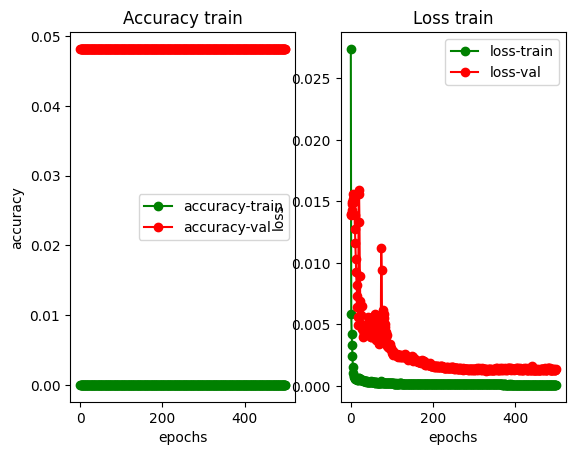

In [14]:
visualizacion_entrenamiento(history_model, 500)

In [15]:
y_predict = model.predict(X_test)

77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


El error es 6.81242283569945e-06
Las dimensiones del Y predict es (2455, 32, 32, 1)
Las dimensiones del Y normal es (2455, 32, 32, 1)


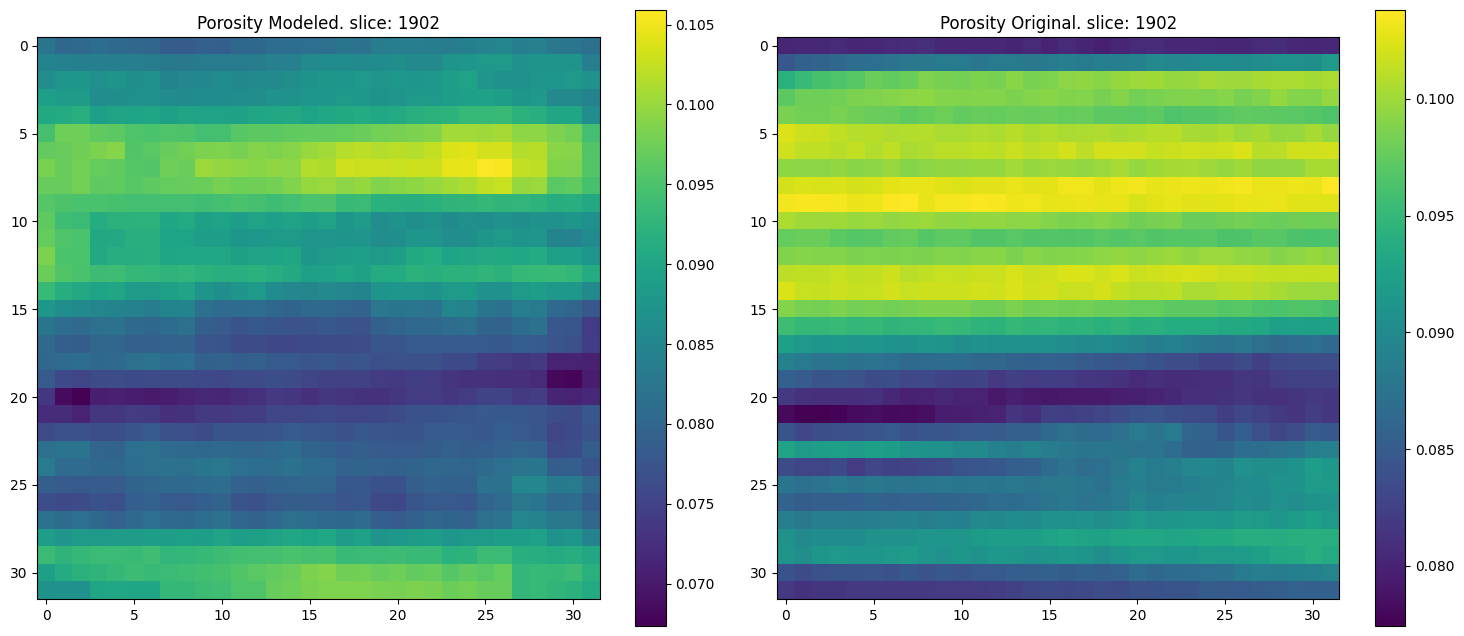

In [16]:
plot_results(y_predict, X_test, Y_test)

El error es 6.81242283569945e-06
Las dimensiones del Y predict es (2455, 32, 32, 1)
Las dimensiones del Y normal es (2455, 32, 32, 1)


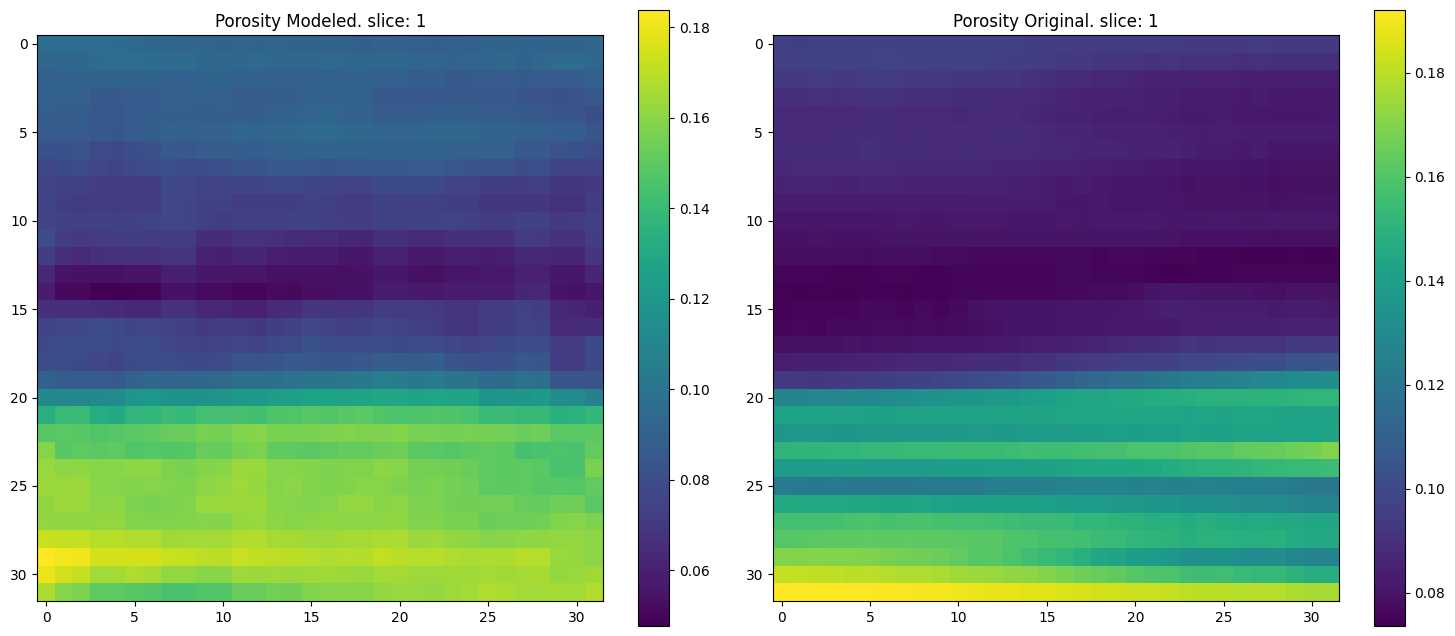

In [17]:
plot_results_by_slices(y_predict, X_test, Y_test, 1)

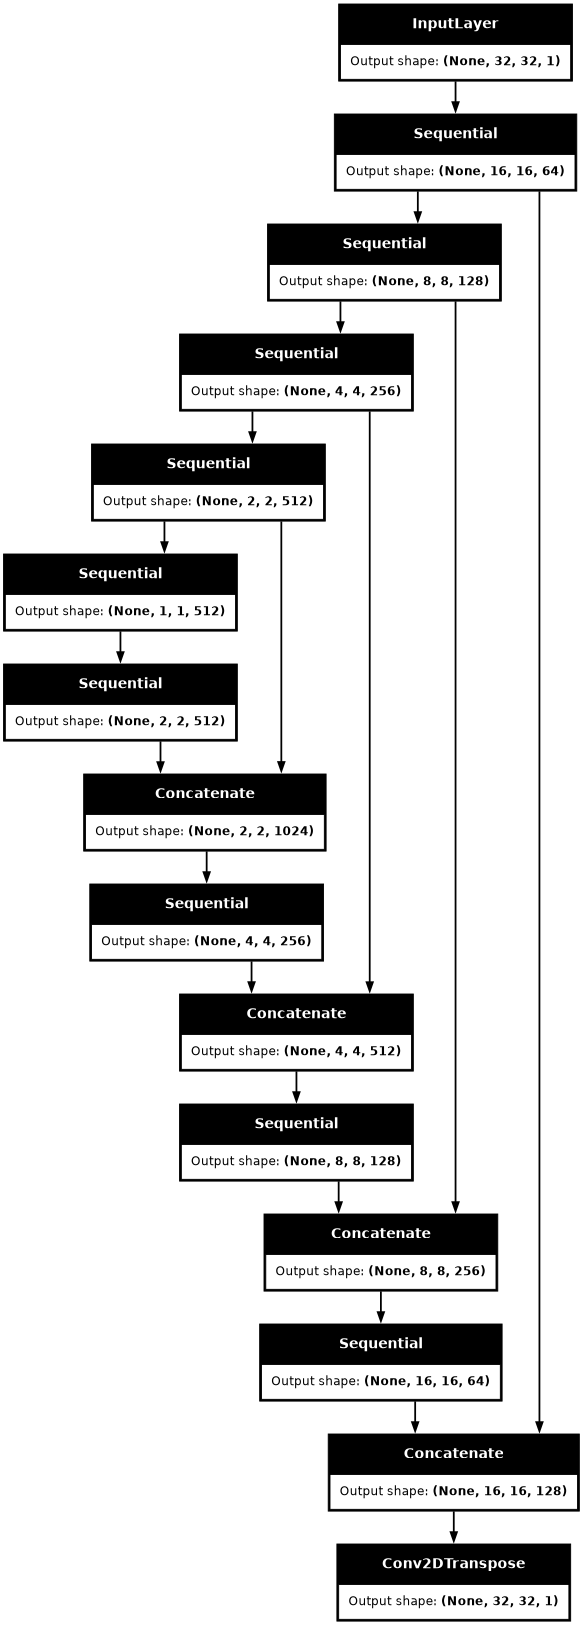

In [18]:
tf.keras.utils.plot_model(model, show_shapes=True, dpi=64,
    to_file='model.png')
